In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-12, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df.columns = df.columns.droplevel(1)  # drop the ticker level -> flat columns
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2014-08-28,22.508841,22.625512,22.356947,22.363550,273840000
2014-08-29,22.563875,22.651930,22.497834,22.643124,178380000
2014-09-02,22.739979,22.836837,22.612300,22.687145,214256000
2014-09-03,21.780190,22.717965,21.700941,22.695952,501684000
2014-09-04,21.599688,22.033353,21.527042,21.760385,342872000
...,...,...,...,...,...
2026-08-21,309.350006,312.380005,307.010010,312.049988,46876800
2026-08-24,310.339996,313.359985,309.970001,311.470001,34673600
2026-08-25,309.899994,313.589996,308.209991,310.790009,25869800


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2014-08-28,22.508841,22.625512,22.356947,22.363550,273840000
2014-08-29,22.563875,22.651930,22.497834,22.643124,178380000
2014-09-02,22.739979,22.836837,22.612300,22.687145,214256000
2014-09-03,21.780190,22.717965,21.700941,22.695952,501684000
2014-09-04,21.599688,22.033353,21.527042,21.760385,342872000


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-08-21,309.350006,312.380005,307.010010,312.049988,46876800
2026-08-24,310.339996,313.359985,309.970001,311.470001,34673600
2026-08-25,309.899994,313.589996,308.209991,310.790009,25869800
2026-08-26,313.450012,315.429993,308.799988,310.299988,34024500
2026-08-27,314.579987,315.399994,309.399994,310.549988,32364000


# 2. Data Exploration and Visualization

In [5]:
df.shape

(3017, 5)

In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
count,3017.000000,3017.000000,3017.000000,3017.000000,3.017000e+03
mean,113.310062,114.443506,112.067609,113.202976,1.113510e+08
std,83.249103,84.068905,82.337507,83.146954,7.149718e+07
min,20.548147,20.850662,20.350264,20.470815,1.791060e+07
25%,36.102245,36.312911,35.791346,36.064552,6.096280e+07
50%,108.669434,110.263662,106.605165,109.124922,9.284480e+07
75%,173.947327,175.575923,171.826063,173.825026,1.380572e+08
max,339.786926,344.273097,337.059318,339.736982,7.593852e+08


In [7]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3017 entries, 2014-08-28 to 2026-08-27
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3017 non-null   float64
 1   High    3017 non-null   float64
 2   Low     3017 non-null   float64
 3   Open    3017 non-null   float64
 4   Volume  3017 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 141.4 KB


In [11]:
df = df.reset_index()

In [12]:
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2014-08-28,22.508841,22.625512,22.356947,22.363550,273840000
1,2014-08-29,22.563875,22.651930,22.497834,22.643124,178380000
2,2014-09-02,22.739979,22.836837,22.612300,22.687145,214256000
3,2014-09-03,21.780190,22.717965,21.700941,22.695952,501684000
4,2014-09-04,21.599688,22.033353,21.527042,21.760385,342872000


<Axes: xlabel='Date', ylabel='Close'>

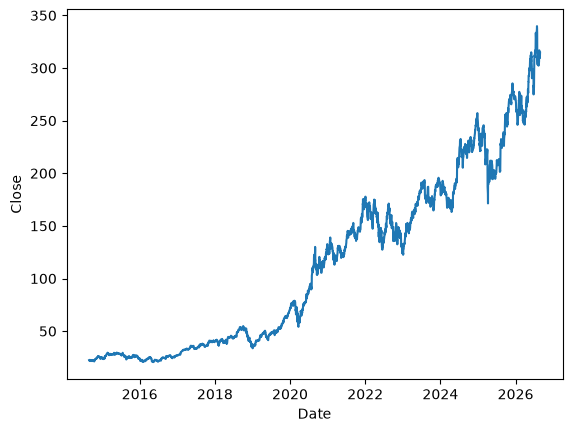

In [13]:
sns.lineplot(data=df, x="Date", y='Close')

# 3.Feature Engineering

### 100 days moving average

In [14]:
df['MA_100'] = df.Close.rolling(100).mean()
df[['Date','Close', 'MA_100']].iloc[95:110]

Price,Date,Close,MA_100
95,2015-01-14,24.275669,NaN
96,2015-01-15,23.616825,NaN
97,2015-01-16,23.433319,NaN
98,2015-01-20,24.036894,NaN
99,2015-01-21,24.220398,23.597276
100,2015-01-22,24.850500,23.620693
101,2015-01-23,24.978739,23.644841
102,2015-01-26,25.005262,23.667494
103,2015-01-27,24.129747,23.690990
104,2015-01-28,25.493872,23.729932


<Axes: ylabel='MA_100'>

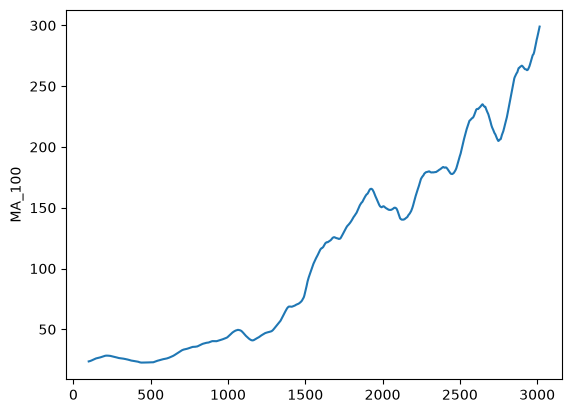

In [15]:
sns.lineplot(df['MA_100'])

Text(0, 0.5, 'Price')

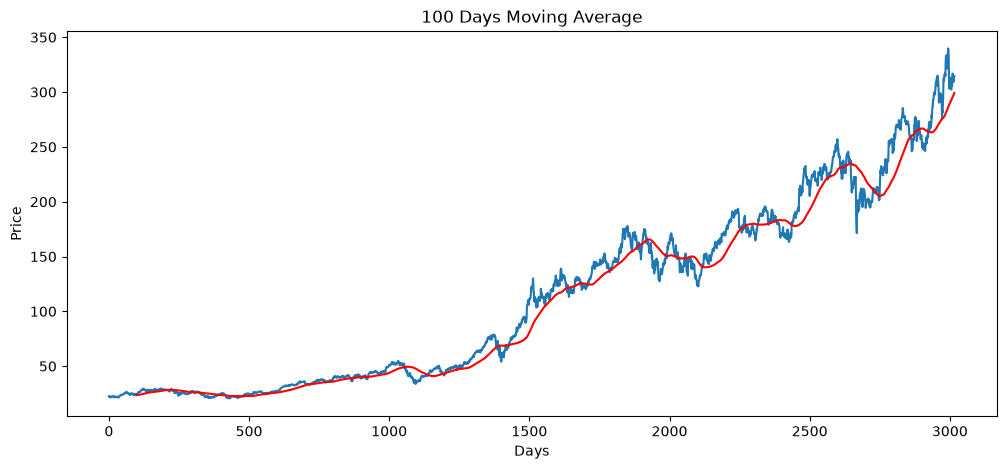

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')
plt.xlabel("Days")
plt.ylabel('Price')

### 200 days moving average

In [17]:
df['MA_200'] = df.Close.rolling(200).mean()
df[['Date','Close', 'MA_200']].iloc[95:110]

Price,Date,Close,MA_200
95,2015-01-14,24.275669,NaN
96,2015-01-15,23.616825,NaN
97,2015-01-16,23.433319,NaN
98,2015-01-20,24.036894,NaN
99,2015-01-21,24.220398,NaN
100,2015-01-22,24.850500,NaN
101,2015-01-23,24.978739,NaN
102,2015-01-26,25.005262,NaN
103,2015-01-27,24.129747,NaN
104,2015-01-28,25.493872,NaN


Text(0, 0.5, 'Price')

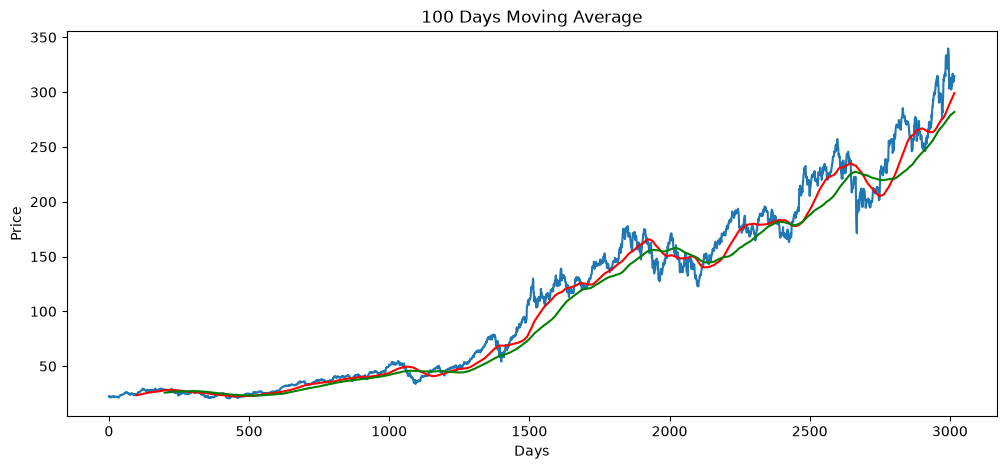

In [18]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('100 Days Moving Average')
plt.xlabel("Days")
plt.ylabel('Price')

### Calculating % changed in each trading session

In [19]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close','Percentage Changed']]

Price,Close,Percentage Changed
0,22.508841,NaN
1,22.563875,0.002445
2,22.739979,0.007805
3,21.780190,-0.042207
4,21.599688,-0.008287
...,...,...
3012,309.350006,-0.006264
3013,310.339996,0.003200
3014,309.899994,-0.001418
3015,313.450012,0.011455


<Axes: ylabel='Percentage Changed'>

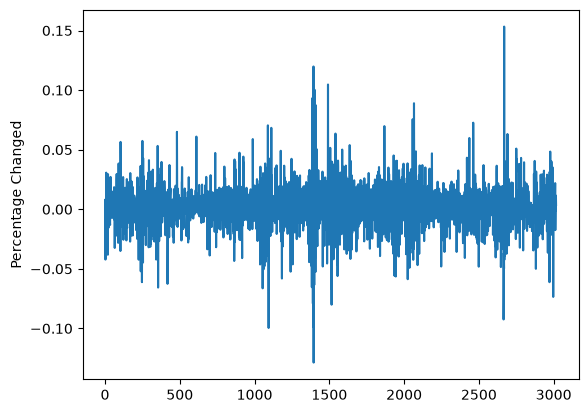

In [20]:
sns.lineplot(data=df['Percentage Changed'])

# 4. Data Preprocessing

In [21]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])

print(data_training)
print(data_testing)

           Close
0      22.508841
1      22.563875
2      22.739979
3      21.780190
4      21.599688
...          ...
2106  128.437500
2107  131.149094
2108  131.070496
2109  132.396820
2110  133.556091

[2111 rows x 1 columns]
           Close
2111  132.838928
2112  132.897888
2113  135.452286
2114  138.635452
2115  140.030548
...          ...
3012  309.350006
3013  310.339996
3014  309.899994
3015  313.450012
3016  314.579987

[906 rows x 1 columns]


### scaling the data between 0 and 1

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [23]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.01246957],
       [0.01281958],
       [0.01393956],
       ...,
       [0.70289737],
       [0.71133249],
       [0.7187052 ]], shape=(2111, 1))

# 5. Sequence Creation

In [24]:
x_train = []
y_train = []
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

# 6. Model Building

In [25]:
import tensorflow as tf

I0000 00:00:1787908300.834790    5482 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787908300.841880    5482 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787908301.460817    5482 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787908303.748741    5482 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [26]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [27]:
model = Sequential() #This accepts the sequence of data

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

E0000 00:00:1787908304.346817    5482 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 7.Model Training

In [28]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - loss: 0.0112
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - loss: 5.4081e-04
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 5.8100e-04
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - loss: 4.9840e-04
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 4.6743e-04
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - loss: 5.4869e-04
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - loss: 4.2137e-04
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - loss: 4.3963e-04
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - loss: 3.7800e-04
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - loss: 3.6004e-04
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 3.8936e-04
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - loss: 4.1787e-04
Epoch 13/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - loss: 3.9021e-04
Epoch 14/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 3.7477e-04
Epo

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [30]:
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [31]:
data_testing

,Close
2111,132.838928
2112,132.897888
2113,135.452286
2114,138.635452
2115,140.030548
...,...
3012,309.350006
3013,310.339996
3014,309.899994
3015,313.450012


In [32]:
past_100_days = data_training.tail(100)

In [33]:
past_100_days

,Close
2011,164.319580
2012,166.771667
2013,160.484512
2014,158.287415
2015,155.864731
...,...
2106,128.437500
2107,131.149094
2108,131.070496
2109,132.396820


In [34]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

,Close
0,164.319580
1,166.771667
2,160.484512
3,158.287415
4,155.864731
...,...
1001,309.350006
1002,310.339996
1003,309.899994
1004,313.450012


In [35]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.19124305],
       [0.20254511],
       [0.17356661],
       ...,
       [0.86224637],
       [0.87860897],
       [0.8838172 ]], shape=(1006, 1))

In [37]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

In [39]:
x_test, y_test = np.array(x_test), np.array(y_test)

# 9. Making Predictions

In [41]:
y_pred = model.predict(x_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


In [42]:
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [43]:
y_pred

array([132.24768, 132.7294 , 132.958  , 133.94693, 135.85019, 137.74074,
       138.6975 , 139.89569, 141.4105 , 141.33434, 141.51904, 142.10358,
       144.55049, 147.76787, 148.71936, 150.11781, 149.91498, 149.1884 ,
       148.85861, 149.85585, 150.368  , 151.46222, 151.51656, 150.9498 ,
       148.93724, 147.75899, 147.36403, 146.20439, 145.86543, 145.57294,
       144.60439, 144.14105, 145.85979, 148.30891, 148.99103, 149.64507,
       149.12791, 147.87184, 147.81651, 148.78976, 149.67487, 151.33089,
       152.05492, 153.33289, 154.91971, 155.2614 , 155.77377, 156.6489 ,
       156.36165, 155.81671, 156.80435, 158.22249, 160.16914, 161.8596 ,
       162.5069 , 161.91548, 161.87946, 160.77003, 159.54672, 158.5779 ,
       160.44121, 161.61652, 162.18477, 162.96655, 163.92252, 164.0083 ,
       163.24193, 162.90022, 162.07764, 161.59853, 163.44946, 165.26375,
       166.18132, 166.08553, 165.44005, 164.30658, 167.23767, 169.15346,
       169.23988, 169.96245, 170.47868, 170.28629, 

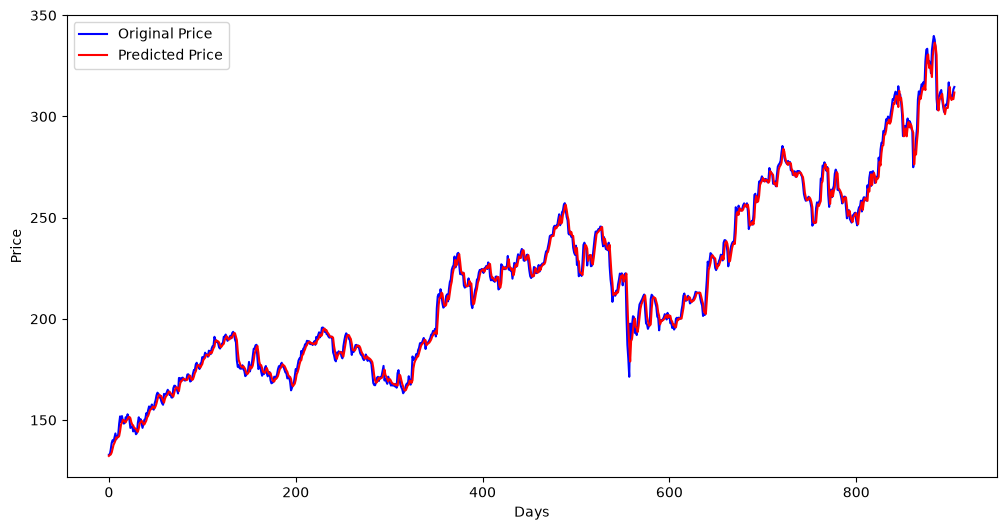

In [46]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_pred, 'r', label='Predicted Price')
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

(140.0, 225.0)

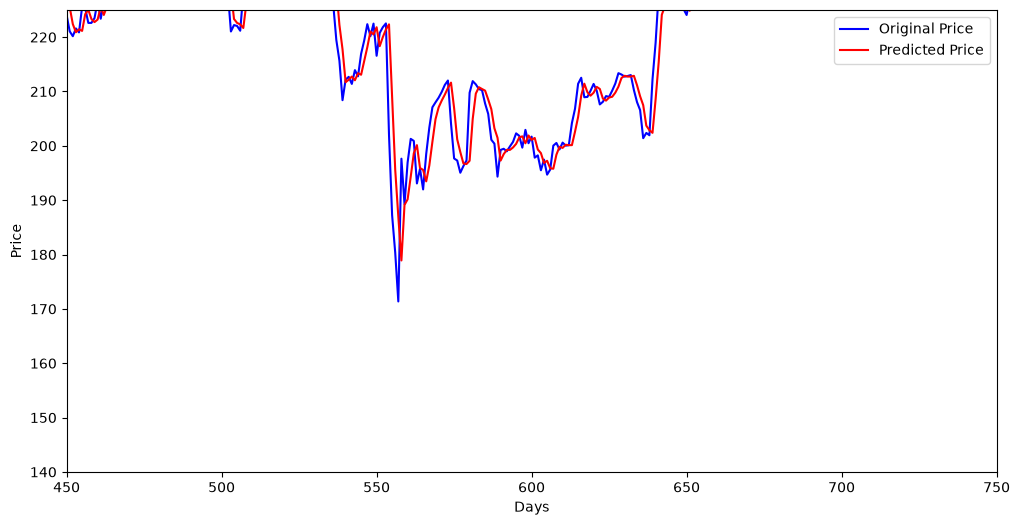

In [45]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_pred, 'r', label='Predicted Price')
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.xlim(450, 750)
plt.ylim(140, 225)

# 10. Model Evaluation

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 15.2367147613989


In [51]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 3.90342346682997


In [52]:
r2 = r2_score(y_test, y_pred)
print(f"R-Squared: {r2}")

R-Squared: 0.9923526309883125
